In [260]:
# Solve with naive NN: ReLU and softmax output; grad descent; L2 regularization.
# Manually implement with numpy.

In [261]:
import numpy as np
from matplotlib import pyplot as plt
from copy import deepcopy # slow but I think this setup is easier to reason through... in future don't do this

from sklearn.datasets import fetch_openml

In [262]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [263]:
def preprocess_mnist(mnist=dict):

    '''
    Reshape and normalize X; one-hot y; train-test split.
    '''

    X, y = mnist.data, mnist.target
    y = y.astype(int)

    X = X / 255

    y = np.eye(10)[y]

    # Shuffle first then split. Fixed seed. Say, 10k in test.

    rng = np.random.default_rng(1)
    indices = rng.permutation(X.shape[0])
    train_size = 60000
    train_idx, test_idx = indices[:train_size], indices[train_size:]

    X_train, X_test = X[train_idx].T, X[test_idx].T
    y_train, y_test = y[train_idx].T, y[test_idx].T

    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    dataset = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    return dataset

    

In [264]:
dataset = preprocess_mnist(mnist)

X_train shape: (784, 60000)
y_train shape: (10, 60000)


In [265]:
def initialize_parameters(dataset: dict, layers=[32, 10], learning_rate=0.1, l2_penalty=0.1):

    params = {}

    params["dataset"] = dataset
    params["cost"] = []
    params["learning_rate"] = learning_rate
    params["l2_penalty"] = l2_penalty
    params["layers"] = layers

    for layer in range(len(layers)):

        size = layers[layer]
        prev_size = layers[layer - 1] if layer != 0 else dataset["X_train"].shape[0]

        # He init
        params[f"W{layer+1}"] = np.random.randn(size, prev_size) * np.sqrt(2 / prev_size)
        params[f"b{layer+1}"] = np.zeros((size, 1))

        params[f"dW{layer+1}"] = np.zeros((size, prev_size))
        params[f"db{layer+1}"] = np.zeros((size, 1))
        
        # params[f"Z{layer+1}"] = np.zeros((size, prev_size))
        # params[f"dZ{layer+1}"] = np.zeros((size, prev_size))
        # params[f"A{layer+1}"] = np.zeros((size, prev_size))

        params[f"activation{layer+1}"] = "relu" if layer != (len(layers) - 1) else "softmax"


    return params

In [266]:
def activation(activation_fxn, input):

    if activation_fxn == "relu":
        return np.maximum(0, input)
    
    elif activation_fxn == "softmax":

        # shape = (layer_size, m)

        # exp(input_i) / sum(exp(inputs))
        # numerical stability for numpy
        exp_input = np.exp(input - np.max(input, axis=0, keepdims=True))
        sum_exp_input = np.sum(exp_input, axis=0, keepdims=True)

        logits = exp_input / sum_exp_input

        return logits

    raise TypeError(f"Invalid activation function! {activation_fxn} passed")

In [267]:
def forward_prop(params: dict, which_data="train"):
    '''
    Iterate:
        Linear combo -> Activation
    '''

    params = deepcopy(params)

    for layer in range(len(params["layers"])):

        A_prev = params[f"A{layer}"] if layer != 0 else params["dataset"][f"X_{which_data}"] # can be reused for X_test
        W = params[f"W{layer+1}"]
        b = params[f"b{layer+1}"]

        params[f"Z{layer+1}"] = W @ A_prev + b
        params[f"A{layer+1}"] = activation(activation_fxn=params[f"activation{layer+1}"], input=params[f"Z{layer+1}"])

    return params

In [268]:
def d_activation(activation_fxn, input):

    if activation_fxn == "relu":

        return 1 * (input > 0)

    elif activation_fxn == "softmax":

        # don't do this... by backprop construction much easier to use two steps together
        raise TypeError("Don't use d_softmax for backprop")

    raise TypeError(f"Invalid activation function! {activation_fxn} passed")

In [269]:
def backward_prop(params: dict, which_data="train"):
    '''
    Iterate:
        Loss -> Gradients
    '''

    params = deepcopy(params)

    l2 = params["l2_penalty"]

    for layer in range(len(params["layers"])-1, -1, -1):

        A = params[f"A{layer+1}"]

        A_prev = params[f"A{layer}"] if layer != 0 else params["dataset"][f"X_{which_data}"]

        if layer == (len(params["layers"])-1):

            y_true = params["dataset"][f"y_{which_data}"]
            m = y_true.shape[1]

            dZ = (A - y_true) / m

        else:

            W = params[f"W{layer+2}"]
            dA = W.T @ dZ
            dZ = dA * d_activation(activation_fxn="relu", input=params[f"Z{layer+1}"])

        dW = dZ @ A_prev.T
        dW += l2 / m * params[f"W{layer+1}"]

        db = np.sum(dZ, axis=1, keepdims=True)

        params[f"dW{layer+1}"] = dW
        params[f"db{layer+1}"] = db

    return params

In [270]:
def calculate_cost(params: dict, which_data="train"):
    ''' 
    Calculate cost and store in cost list. Cross-entropy
    '''

    params = deepcopy(params)

    y_true = params["dataset"][f"y_{which_data}"]

    pred_dict = forward_prop(params, which_data)
    idx = len(pred_dict["layers"])
    y_pred = pred_dict[f"A{idx}"]
    y_pred = np.clip(y_pred, 1e-15, 1)

    m = y_true.shape[1]

    cost = -np.sum(y_true * np.log(y_pred)) / m
    l2 = params["l2_penalty"]
    cost += (l2 / (2*m)) * sum(np.sum(params[f"W{i+1}"] ** 2) for i in range(len(params["layers"])))

    params["cost"].append(cost)

    return params

In [271]:
def update_weights(params: dict):
    ''' 
    Grad descent + L2
    '''

    params = deepcopy(params)

    l2 = params["l2_penalty"]
    lr = params["learning_rate"]

    for layer in range(len(params["layers"])):

        params[f"W{layer+1}"] -= lr * (params[f"dW{layer+1}"])# + l2 * params[f"W{layer+1}"])
        params[f"b{layer+1}"] -= lr * (params[f"db{layer+1}"])

    return params

In [272]:
def single_epoch(params: dict):

    params = deepcopy(params)

    params = forward_prop(params, "train")

    params = calculate_cost(params, "train")

    params = backward_prop(params, "train")

    params = update_weights(params)

    return params

In [273]:
def calculate_accuracy(params: dict, which_data = "train"):

    params = deepcopy(params)

    y_true = np.argmax(params["dataset"][f"y_{which_data}"], axis=0)

    pred_dict = forward_prop(params, which_data)
    idx = len(pred_dict["layers"])
    y_pred = pred_dict[f"A{idx}"]
    y_pred = np.argmax(y_pred, axis=0)

    accuracy = np.mean(y_true == y_pred)

    return accuracy

In [274]:
def train_mnist():

    params = initialize_parameters(dataset)

    for epoch in range(1000):

        # print(epoch)

        params = single_epoch(params)

        if epoch % 50 == 0:

            train_accuracy = calculate_accuracy(params, which_data="train")
            print("Epoch:", epoch, "Cost:", np.round(params["cost"][-1], decimals=3), "Accuracy:", np.round(train_accuracy, decimals=3))

    test_accuracy = calculate_accuracy(params, which_data="test")

    print("Test set accuracy:", test_accuracy)

    plt.plot(params["cost"])

Epoch: 0 Cost: 2.37 Accuracy: 0.172
Epoch: 50 Cost: 0.687 Accuracy: 0.838
Epoch: 100 Cost: 0.48 Accuracy: 0.876
Epoch: 150 Cost: 0.412 Accuracy: 0.889
Epoch: 200 Cost: 0.376 Accuracy: 0.897
Epoch: 250 Cost: 0.353 Accuracy: 0.903
Epoch: 300 Cost: 0.336 Accuracy: 0.907
Epoch: 350 Cost: 0.323 Accuracy: 0.91
Epoch: 400 Cost: 0.312 Accuracy: 0.913
Epoch: 450 Cost: 0.302 Accuracy: 0.915
Epoch: 500 Cost: 0.294 Accuracy: 0.918
Epoch: 550 Cost: 0.287 Accuracy: 0.92
Epoch: 600 Cost: 0.28 Accuracy: 0.922
Epoch: 650 Cost: 0.274 Accuracy: 0.923
Epoch: 700 Cost: 0.268 Accuracy: 0.925
Epoch: 750 Cost: 0.263 Accuracy: 0.926
Epoch: 800 Cost: 0.258 Accuracy: 0.927
Epoch: 850 Cost: 0.253 Accuracy: 0.929
Epoch: 900 Cost: 0.248 Accuracy: 0.93
Epoch: 950 Cost: 0.244 Accuracy: 0.931
Test set accuracy: 0.9255


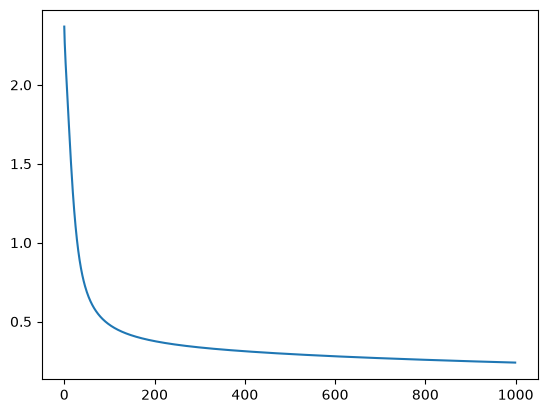

In [275]:
train_mnist()